#Clustering K-means

En esta notebook vamos a explorar un metodo de clusterización visto en la clase teórica. El método de clusterización que veremos corresponde a la rama de ML de aprendizaje no supervisado donde la idea principal es encontrar grupos en los datos que sean similares a otros datos del mismo grupo y lo menos similar posible a datos en otros.

El método es el algoritmo de partición **K-Means**, que aplicaremos al dataset de caras Olivetti, para tratar de agrupar las fotos según la persona a la que se le sacó la foto.


In [ ]:
# importamos las librerías usuales de python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# importamos los algoritmos de clusterizacion a utilizar en esta notebook
from sklearn.cluster import KMeans  # K-means

## [K-Means](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html#sklearn.cluster.KMeans)

El método de clusterización "K-Means" busca encontrar _k_ clusters de modo tal que se minimice la varianza intra-cluster medida, usualmente, como el cuadrado de la distancia euclídea. Para ello el algoritmo empieza encontrando _k centroids_ y le asigna a cada sample la etiqueta correspondiente a la del centroid más cercano. Una vez actualizadas las etiquetas de todas las samples, calcula la posición de los k centroids (como el promedio de las features de las samples de cada cluster) y vuelve a asignar etiquetas a cada sample de acuerdo a la distancia al centroid más cercano. Hace estos dos pasos hasta que no haya más cambios de etiqueta.

Debido a esta inicialización aleatoria de los k centroids el output del modelo puede variar al aplicarlo otra vez a la misma data. Por ello se repite este procedimiento n_init=10 veces y el output final es el que mejor resultado tuvo al minimizar la función objetivo (varianza intra-cluster).


### Clustering en el dataset de caras Olivett

El dataset consta de 10 fotos de 64\*64 pixeles en escala de grises de 40 personas distintas (400 fotos en total). Cada sample (foto) importada es un vector de 4096 elementos, los cuales representan las filas de pixeles ordenadas de arriba hacia abajo de la foto. Es decir, los primeros 64 elementos corresponden a la fila superior de pixeles de la imagen y así sucesivamente.


In [2]:
from sklearn.datasets import (
    fetch_olivetti_faces,
)  # para cargar el dataset de caras

data, targets = fetch_olivetti_faces(return_X_y=True)  # cargamos las caras

print("Dimensión de los datos {}".format(data.shape))

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /home/toopazo/scikit_learn_data
Dimensión de los datos (400, 4096)


Gráficamos las imágenes, pero de solo 2 dimensiones. Puede jugar con cuales dimensiones gráficar.


Text(0.5, 1.0, 'Proyección 2D del dataset Olivetti coloreada por persona')

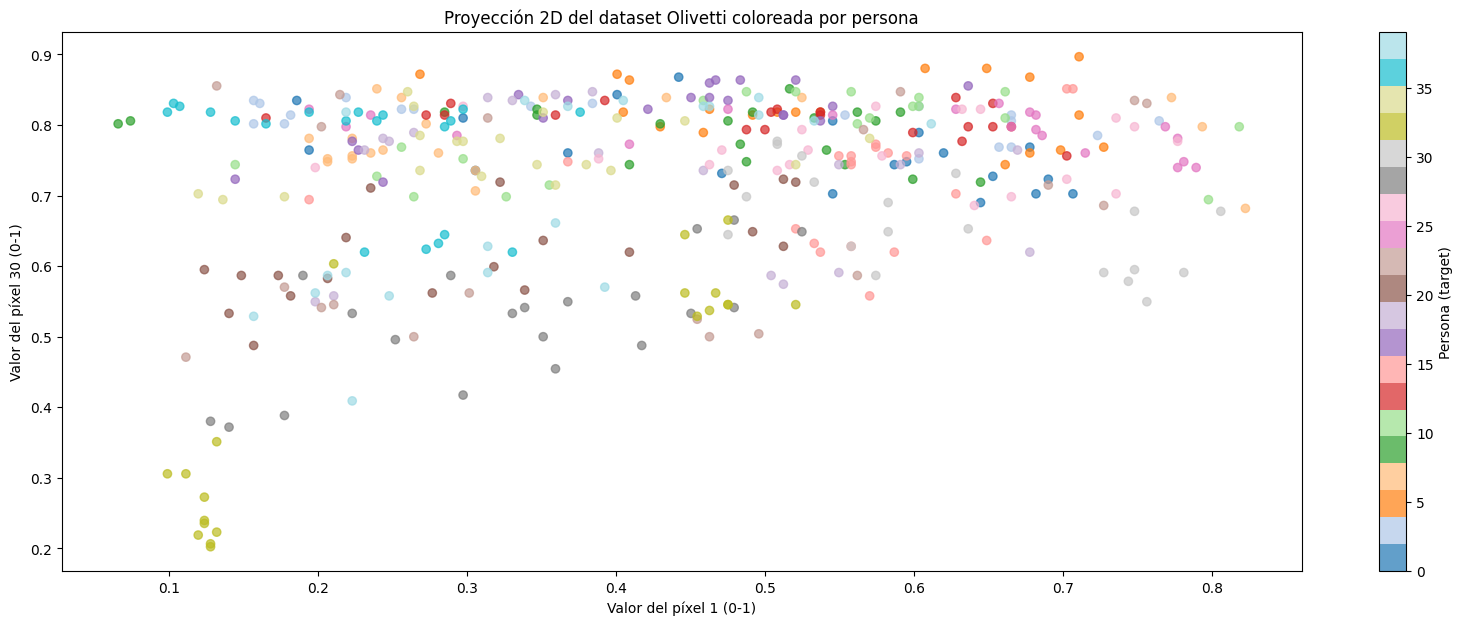

In [14]:
fig, ax = plt.subplots(figsize=(20, 7))

# dimensiones
d1 = 1
d2 = 30

# Coloreamos cada punto según la persona (target) a la que pertenece
sc = ax.scatter(data[:, d1], data[:, d2], c=targets, cmap="tab20", alpha=0.7)
plt.colorbar(sc, ax=ax, label="Persona (target)")

ax.set_xlabel(f"Valor del píxel {d1} (0-1)")
ax.set_ylabel(f"Valor del píxel {d2} (0-1)")
ax.set_title("Proyección 2D del dataset Olivetti coloreada por persona")

Ahora aplicamos el método de clusterización K-Means para agrupar las fotos en base a sus componentes principales. Como sabemos que el dataset consta de 40 personas diferentes utilizamos esta información para pedirle al algoritmo que encuentre k=40 clusters con la esperanza que podamos agrupar las fotos según la persona que está en ella.


In [4]:
# Creación del modelo KMeans con k = 40
kmeans = KMeans(n_clusters=40)

# Ajuste del modelo a los datos reducidos en componentes principales
kmeans.fit(data)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",40
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


Para acceder a las etiquetas que le asignó el modelo a cada sample usamos 'kmeans.labels\_'


In [5]:
# Nos fijamos las etiquetas asignadas a las primeras 10 muestras y los counts que recibió cada una
np.unique(kmeans.labels_[:10], return_counts=True)

(array([13, 17, 25, 32, 35], dtype=int32), array([3, 1, 3, 1, 2]))

Idealmente queríamos tener una sola etiqueta en las primeras 10 muestras ya que corresponden a las fotos tomadas a una persona. Sin embargo obtuvimos 5 etiquetas distintas. **Esto dependerá que cuales dimensiones analizamos**

Veamos qué es lo que está pasando. Vamos a plotear el dataset, pero además vamos a asignarle un color a cada sample que corresponde a la etiqueta asignada por el modelo. También vamos a graficar con una "X" el centroid de cada cluster.

Para acceder a la posición de los centroids en el espacio de 100 PCs usamos 'kmeans.cluster*centers*'


In [6]:
# Guardo las posiciones de los centroids
centroids = kmeans.cluster_centers_

# Muestro las dimensiones de las posiciones
print("Shape de los centroids:", centroids.shape)
# Printeo las posiciones de las primeras 5 muestras en sus primeras dos componentes principales
print(centroids[:5, [d1, d2]])

Shape de los centroids: (40, 4096)
[[0.2121212  0.75206614]
 [0.5048701  0.6490555 ]
 [0.20661156 0.56382   ]
 [0.5665289  0.80619836]
 [0.37762237 0.6280992 ]]


/tmp/ipykernel_26161/1478035413.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Text(0, 0.5, 'Segunda dimensión')

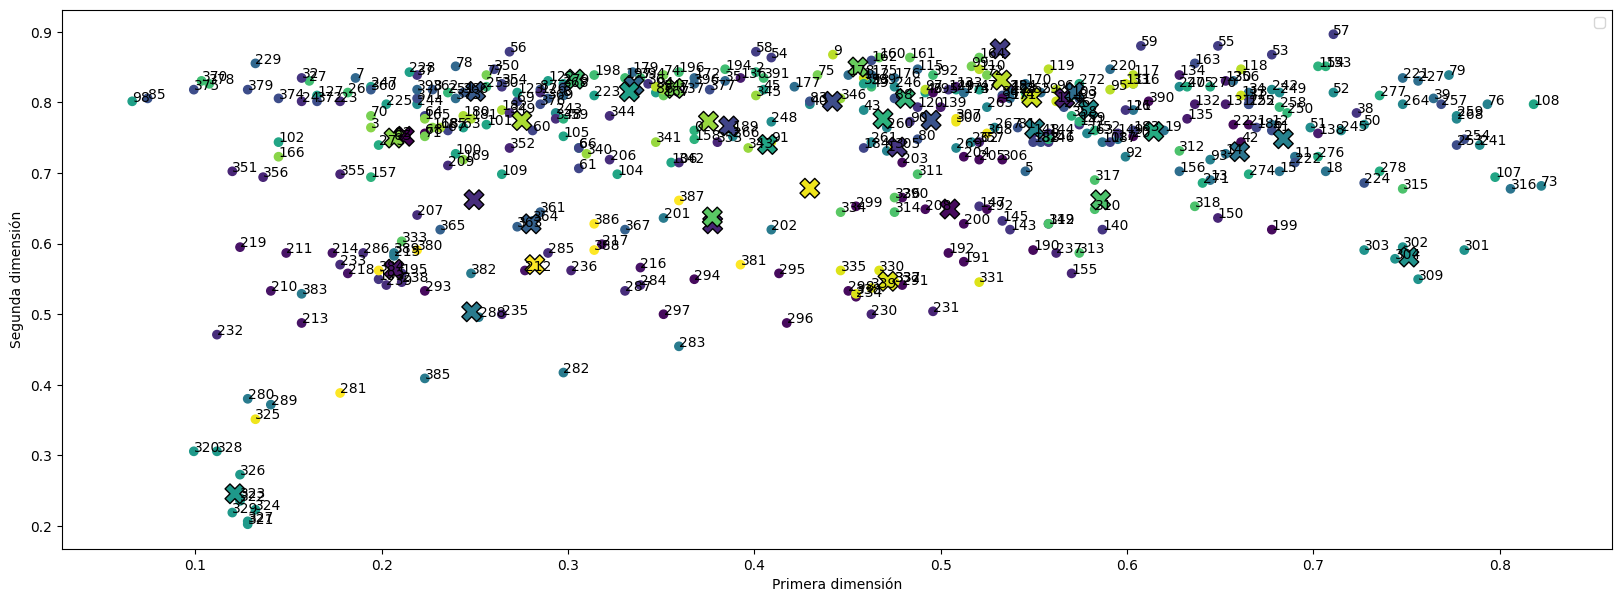

In [7]:
# Este bloque es similar al anterior pero agregando color a cada sample en el scatter plot según la etiqueta asignada

fig, ax = plt.subplots(figsize=(20, 7))


# Hacemos un scatter plot de cada uno de los datos
ax.scatter(data[:, d1], data[:, d2], c=kmeans.labels_)
ax.scatter(
    centroids[:, d1],
    centroids[:, d2],
    marker="X",
    s=200,
    linewidths=1,
    c=np.unique(kmeans.labels_),
    edgecolors="black",
)
ax.legend()

## Por cada dato escribimos a qué instancia corresponde. Pueden comentar estas 2 lineas para ver mejor los colores
for i in range(data.shape[0]):
    ax.text(data[i, d1], data[i, d2], s=i)

ax.set_xlabel("Primera dimensión")
ax.set_ylabel("Segunda dimensión")

En este plot podemos ver que hay samples más alejados de la nube principal de puntos que tienen un color definido.

Dependiendo de las variables graficadas, la distribución podria ser diferente. Pruebe graficando otras dimensiones

Parecería ser que los clusters que encuentra no son los que queríamos que nos diera el modelo. Pero entonces, ¿qué son estos clusters? Mostremos las imágenes correspondientes a cada cluster.


In [8]:
labels = kmeans.labels_

for i in range(40):
    index = np.nonzero(labels == i)[0]
    num = len(index)
    if num > 0:  # Only plot if the cluster is not empty
        this_faces = data[index].reshape(len(index), 64, 64)
        fig, axes = plt.subplots(
            1,
            num,
            figsize=(24, 4),
            subplot_kw={"xticks": [], "yticks": []},
            gridspec_kw=dict(hspace=0.1, wspace=0.1),
        )
        fig.suptitle("Cluster " + str(i), fontsize=20)
        # Ensure axes is an array even if num is 1, so axes.flat works consistently
        if num == 1:
            axes = np.array([axes])
        for j, ax in enumerate(
            axes.flat
        ):  # Changed inner loop variable to 'j' to avoid shadowing
            ax.imshow(this_faces[j], cmap="bone")
        plt.close(fig)  # Close the figure after it's displayed to save memory

Podemos ver que varios clusters son imágenes de una sola persona, lo cual esta muy bien. Pero en otros casos, no agrupa bien.

Revise los cluster y vea las similitudes.


A pesar de que en los primeros gráficos no se apreciaba una buena clusterización, pudimso ver que varios clusters si tienen imágenes de una misma persona.


#### [Método del codo](<https://en.wikipedia.org/wiki/Elbow_method_(clustering)#:~:text=In%20cluster%20analysis%2C%20the%20elbow,number%20of%20clusters%20to%20use.>)

Se hace un grafico de la función objetivo en función de la elección de k y se elige el k correspondiente al punto donde agregar un cluster más no baja significativamente el valor que queremos minimzar. Esto se puede detectar a ojo o utilizando algún paquete de python como ['kneed'](https://raghavan.usc.edu//papers/kneedle-simplex11.pdf)


In [9]:
!pip install kneed            # instalamos el paquete con pip
from kneed import KneeLocator # importamos el paquete para detectar el codo

Vamos a aplicar el método KMeans al dataset de caras pero cambiando el número de clusters k y guardaremos el puntaje de la función objetivo, SSE (suma de los cuadrados de la distancia euclidea de cada cluster), en una lista


In [10]:
# esto puede demorar un par de minutos

sse = []  # acá vamos a guardar el puntaje de la función objetivo

for k in range(1, 40):
    print(k)
    kkmeans = KMeans(n_clusters=k)
    kkmeans.fit(data)
    sse.append(kkmeans.inertia_)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39


Vamos a graficar SEE en función del número de clusters k


Text(0, 0.5, 'SSE')

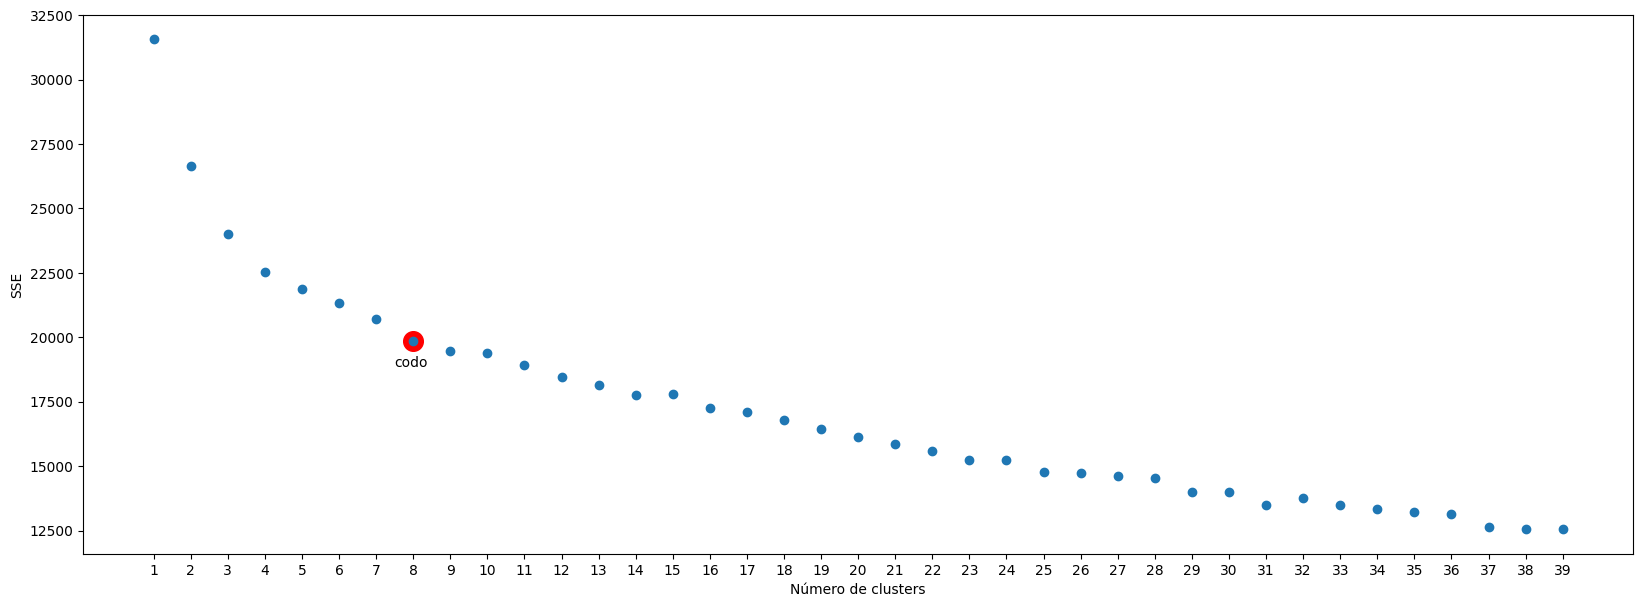

In [11]:
fig, ax = plt.subplots(figsize=(20, 7))

# esta dos lineas las agrego para que se vea la elección de KneeLocator para el codo en este gráfico
ax.scatter(
    8, sse[7], color="red", s=200
)  # agregamos un punto rojo al plot de tamaño s=200 en el lugar donde se encuentra el codo
ax.text(
    7.5, sse[7] - 1000, s="codo"
)  # agregamos un texto abajo para indicar qué representa el punto

# estas lineas son el grafico de SSEvsK
ax.scatter(range(1, 40), sse)
ax.set_xticks(range(1, 40))
ax.set_xlabel("Número de clusters")
ax.set_ylabel("SSE")

En este plot podemos ver dos cosas:

1. SSE es monótonamente decreciente: al agregar un cluster la distancia entre todas las samples a los centroides siempre va a reducirse
2. A ojo distinguimos un codo entre k=7 y k=16 porque al agregar más clusters aumentamos la complejidad del modelo pero SEE disminuye en menor proporción.

Aun así, es muy dificil detectar el codo exactamente con la gráfica. No son muchos los casos donde con un gráfico podamos detectar el codo facilmente.


Usamos la función 'KneeLocator' para detectar el codo. Para ello le tenemos que pasar los valores de K, SEE, la forma de la fución (cóncava o convexa) y la dirección (creciente o decreciente)


In [12]:
kl = KneeLocator(range(1, 40), sse, curve="convex", direction="decreasing")

print("El codo está en k =", kl.elbow)

El codo está en k = 8


## Resumen de funciones utilizadas e importantes.

KMeans

```
from sklearn.cluster import KMeans  # Importamos la clase KMeans

kmeans = KMeans(n_clusters=k)       # Crear el modelo con k-clusters

kmeans.fit(datos)                   # Ajustar el modelo a los datos

labels = kmeans.labels_             # Obtener las etiquetas de los k clusters para cada sample

centroids = kmeans.cluster_centers_ # Obtener las posiciones en el espacio de features del centro de los k clusters

sse = kmeans.inertia_               # Para obtener el valor de la función objetivo
```

Elección de k (si no lo conocemos de antemano):

Método del codo

```
!pip install kneed            # Instalamos el paquete kneed con pip install

from kneed import KneeLocator # Importamos la clase para detectar el codo

kl = KneeLocator(range(1, 40), sse, curve="convex", direction="decreasing") # Clase que sirve para calcular el codo en un gráfico de la función objetivo. Se le dan los puntos de la función con sus respectivos k, el tipo de curva (convexa o cóncava) y el sentido (creciente o decreciente)

kl.elbow                      # Devuelve el valor del codo
```
